# EMG Preprocessing Tutorial
@johanachard, 2026

**From raw BDF recordings to manually validated EMG onsets**

It follows four steps:

1. **Extract and preprocess EMG signal** from the BDF file.
2. **Correct response-marker timing** by aligning BDF response triggers with behavioral reaction times.
3. **Detect EMG onset/offset automatically** using threshold-based burst detection.
4. **Visualize, inspect, and manually correct** EMG markers before saving the final event files.


### Pipeline overview

Note that **the signal and the event markers are processed separately, then combined again before manual validation**.

- The **signal** is extracted, bipolar-referenced, filtered, and saved as a `.fif` file.
- The **events** are extracted from the BDF file, then response markers are corrected using the behavioral file.
- The corrected events are used to segment the EMG signal into stimulus-locked trials.
- Automatic onset/offset markers are added and then manually checked.

### Recommandations
Recommended output structure:

```text
EMG_processing/
├── processed_data_STEP1/
│   ├── EMG_signals/
│   └── triggers/
└── processed_data_STEP2/
    ├── segmented/
    └── continuous/
```


Remember your triggers, for example:

| Event type | Codes |
|---|---|
| Stimulus onset | `1,2,3,4,5,6,7,8,9` |
| Responses trigger | `100, 101, 102, 103` |
| YOUR conditions | `................` |
| No response / too late | `200` |
| EMG onset marker | `350` |
| EMG offset marker | `351` |

In [1]:
# if need for visualisation : pip install PyQt5-tools

# Library
import os
import sys 
current = os.path.join(os.getcwd()) # find current file
os.chdir(os.path.join(current, "toolbox_EMG"))

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import arviz as az
import mne
import copy
import emgTools as emg
import evtTools as evt
from Events import Events
import vizEMG
import useMne

mne.set_log_level('WARNING')  # ou 'ERROR' pour encore moins de messages
az.style.use('arviz-white')
np.set_printoptions(5, suppress=True) # afficher les nombre a 5decimal

## Step 1 - Average, bipolar derivation, filter, RT lag correction
### 1.1. Load `.bdf` file

First, selected subject and load corresponding bdf data file:

In [2]:
# ------ Select subject and load data
nameSubj = 's1'# there 3 times where I defined the subject name, thank to modify when you change subject !! 

data_fname = os.path.join(current, 'data/' + nameSubj + '.bdf')
raw = mne.io.read_raw_bdf(data_fname, preload=True)

# Info (rate and channel names)
sf = raw.info['sfreq']#sampling rate
ch_names = raw.ch_names#channel names
print ("successful EMG data loading")

raw

successful EMG data loading


<RawEDF | s1.bdf, 5 x 2980864 (2911.0 s), ~113.7 MiB, data loaded>

Now, we can extract triggers from bdf file. 

The first column is the sample of the event (1024 samples = 1 second) since recording onset, second column is trigger (either stimulus or response).

In [3]:
#------ Extract trigger events from raw files 
raw_events = mne.find_events(raw)   # shortest_event=1 
raw_events  # shape (time in sample; channel 0 if left and 1 right, triggers)

array([[    557,   65536,   65567],
       [    968,   65536,   65541],
       [   8678,       0,      40],
       ...,
       [2962874,       0,       6],
       [2963300,       0,     103],
       [2963316,       0,      31]], shape=(5822, 3))

You can check number ot trials, conditions, etc., if you want:

In [4]:
# np.where(raw_events == 32)  #!!!!!! check 
# df = pd.DataFrame(raw_events)
# print(df[df.iloc[:, -1] == 32])
# #df.to_csv('output.csv')

print('done.')

done.


### 1.2. Extract EMG channels and compute bipolar derivation

**Goal**: convert the raw BDF file into a clean two-channel EMG signal.

The original pipeline does the following:

1. Load the `.bdf` file.
2. Extract raw trigger events.
3. Keep `EXG1`, `EXG2`, `EXG3`, and `EXG4`.
4. Compute bipolar derivations:
   - `EMGL = EXG1 - EXG2`
   - `EMGR = EXG3 - EXG4`
5. Apply a 10 Hz high-pass filter.
6. Save the filtered bipolar signal as `{subject}_EMGstep1.fif`.

The plot below is a quality check: it compares the unfiltered bipolar EMG with the filtered EMG over a short segment.

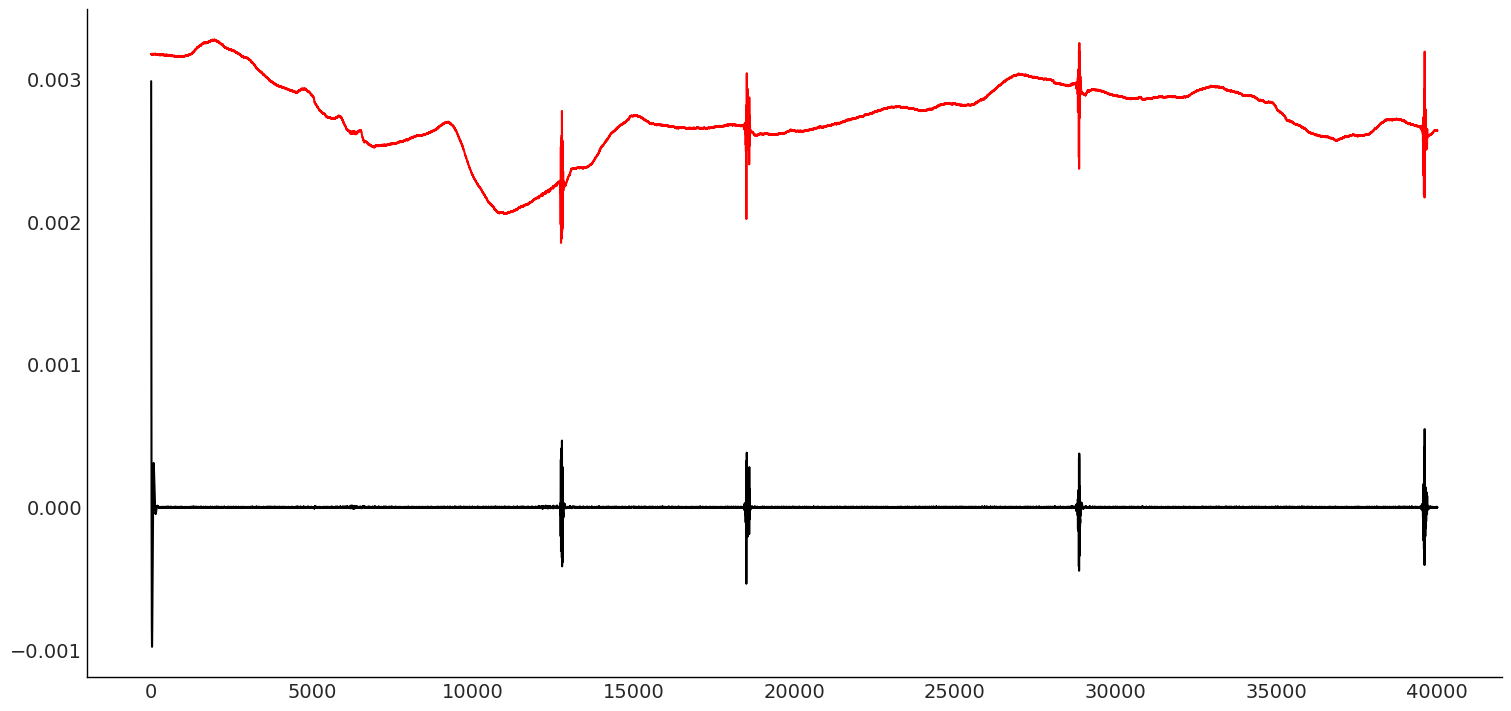

In [5]:
# -------- Extract EMG channels and compute bipolar derivation

# Select EXG channels 1 2 3 4 with 1 for left hand down, 2 for left hand up,  3 and 4 for right hand down and up
# This line of code ensures that we are only considering EMG channels)
raw_select_EMG = raw.copy().pick_channels(['EXG1','EXG2', 'EXG3', 'EXG4'], ordered = True)

#bipolar derivation: EMGL = EXG1 - EXG2  and  EMGR = EXG3 - EXG4 
raw_bipolar = mne.set_bipolar_reference(raw_select_EMG, ['EXG1','EXG3'], ['EXG2','EXG4'], ch_name=['EMGL','EMGR'], copy=True)

#apply a 10hz high-pass filter to data (i.e remove all frequencies below 10 Hz from the signal)
raw_bipolar_filtered = useMne.applyFilter(raw_bipolar, ch_names = ['EMGL','EMGR'],low_cutoff = 10)

# Get the EMG data
EMG_data = raw_bipolar_filtered.get_data(picks=['EMGL','EMGR']) # filtered
EMG_data_NF = raw_bipolar.get_data(picks=['EMGL','EMGR']) # not filtered

# -----Plot EMG data section
l = 0
h = 40000 # le max est dans raw_bipolar, p.ex., 8273919 
x = np.arange(l,h)
plt.figure (1, figsize = (15, 7))
# left plot
plt.plot(x,EMG_data[0, l:h], color = 'black')
plt.plot(x,EMG_data_NF[0,l:h], color = 'red')
# right plot
# plt.plot(x,EMG_data[1, l:h], color = 'blue', alpha = .5)
# plt.plot(x,EMG_data_NF[1,l:h], color = 'orange', alpha = .2)
plt.show()



### 1.3. Correct response-marker lag using behavioral RTs

**Goal**: for technical reasons, RTs collected in the behavioral datafile are more accurate than the response triggers in the EMG file.
For this reason, let's adjust the response triggers based on the behavioral datafile (you can ignore this section, as it is a bit technical). 

At the end, the diagnostic plot should show:
- **before correction:** visible lag between BDF RT and behavioral RT (around 1 frame = 16ms);
- **after correction:** points centered around zero.

In [6]:
# Load behavioral data ----
behavioral_data = pd.read_csv(current + f"\{nameSubj}.txt")

# select corresponding data (block != 0) to avoid the first block which is a training block (if i understand correctly the task)
data_select =  behavioral_data[behavioral_data["block"] != 0]
data_select

<string>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
<string>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
C:\Users\erc\AppData\Local\Temp\ipykernel_14792\1101490591.py:2: SyntaxWarning: invalid escape sequence '\{'
  behavioral_data = pd.read_csv(current + f"\{nameSubj}.txt")
<string>:2: SyntaxWarning: invalid escape sequence '\{'


,subject_id,trial_tot,block,trial_block,swrep,csi,fixtime,corr_resp,key_pressed,accuracy,RT,trigg_stim,trigg_resp,trigg_cue,trigg_fix,trigg_blank
82,1,1,5,1,fill,1.0,0.3,2,2,1,0.674902,9,103,11,40,31
83,1,2,5,2,rep,0.1,0.3,1,1,1,1.200502,4,101,12,40,32
84,1,3,5,3,rep,0.1,0.3,2,2,1,1.117533,7,103,11,40,32
85,1,4,5,4,sw,0.1,0.3,1,1,1,1.038582,2,101,22,40,32
86,1,5,5,5,rep,0.1,0.3,2,2,1,1.541635,9,103,21,40,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,1,1160,16,93,rep,1.0,0.3,2,2,1,0.481603,9,103,21,40,31
1242,1,1161,16,94,sw,0.1,0.3,2,2,1,0.520905,6,103,12,40,32
1243,1,1162,16,95,rep,1.0,0.3,1,1,1,0.338080,4,101,11,40,31
1244,1,1163,16,96,rep,0.1,0.3,1,1,1,0.467444,2,101,12,40,32


We extract response time (RT):

In [7]:
RT = (data_select['RT']*1000).to_numpy() # in ms
RT.shape

(1164,)

Following code calculates response times (RT) by subtracting the selected event of interest (start of RT) from the response time in a BDF file using corresponding trigger (here response triggers are 100, 101, 102, 103). It then compares them to behavioral RTs while counting valid and missed trials.

In [8]:
# Find RT in bdf file by computing time sample response - stimulus triggers
RT_bdf = []
RT_without_misses = []#select RT from the behavioral file (removing missed trials)
miss = 0
strange = 0

counter = 0 # to keep track of each trial
for i in range (len(raw_events)):#loop over triggers from the EMG file
     
    if raw_events[i,  2] == 200: # missed trial
        miss += 1
        counter += 1
    
    if raw_events[i,  2] == 127: # strange trial
        strange += 1
        counter += 1
        
    if raw_events[i,  2] in [100, 101, 102, 103]: # a response has been given by the subject 
        #convert the sample corresponding to each event  (stimulus and response) into time (in ms); 
        #to do that, we divide the sample by the sampling rate (1024) and multiply the result by 1000
        #we then compute time of the response - time of the stimulus to get the RT
        
        a = (raw_events[i, 0]/sf)*1000 - (raw_events[i-1, 0]/sf)*1000  # RT bdf file
        b = RT[counter] # RT behavior data
        RT_bdf.append(a)
        RT_without_misses.append(b)
        
        counter += 1

RT_bdf = np.array(RT_bdf) 
RT_without_misses = np.array(RT_without_misses)
print("Trials number:", counter, '/ 1164')
print("Trials missed:", miss)

Trials number: 1164 / 1164
Trials missed: 0


Newt, the following cell corrects the response markers in the BDF file to align them with the behavioral data. It then recalculates the corrected RTs and measures the remaining difference from the behavioral RTs.

In [9]:
# Convert RT from the behavioral file into samples
RT_converted = np.round(1024*RT/1000)
# Make a deep copy of the event file
corrected_events = copy.deepcopy(raw_events[:,(0,2)])

# --- Compute corrected RTs and compare with behavioral datafile -----
counter = 0
for i in range (len(corrected_events)):
    if corrected_events[i, 1] == 200:
        counter = counter + 1 #don't modify the "missed trial" marker
    elif corrected_events[i, 1] in [100,101,102,103]: 
        corrected_events[i, 0] = corrected_events[i-1, 0] + RT_converted[counter] # adjust the timing of response markers to match the behavioral datafile
        counter = counter + 1

if counter == 97: #because there are 900 trials
    print ("Correction of response markers completed")
else: ValueError("PROBLEM with the correction of response markers")


RT_bdf_corrected = []
for i in range (len(corrected_events)):
    if corrected_events[i, 1] in [100, 101, 102, 103]: 
        RT_bdf_corrected.append((corrected_events[i, 0]/1024)*1000 - (corrected_events[i-1, 0]/1024)*1000)
RT_bdf_corrected = np.array(RT_bdf_corrected)    
lag_after = np.array(RT_without_misses - RT_bdf_corrected)

lag_before = RT_bdf - RT_without_misses  #compute difference between RT in the bdf file and RT in the behavioral file

Finally, we plot two graphs comparing the time lags between behavioral RTs and those of the BDF, before and after correction. The first shows the initial differences (should be around one frame = 15-20ms), the second the residuals after alignment (around 0).

Text(0, 0.5, 'RT lag (ms)')

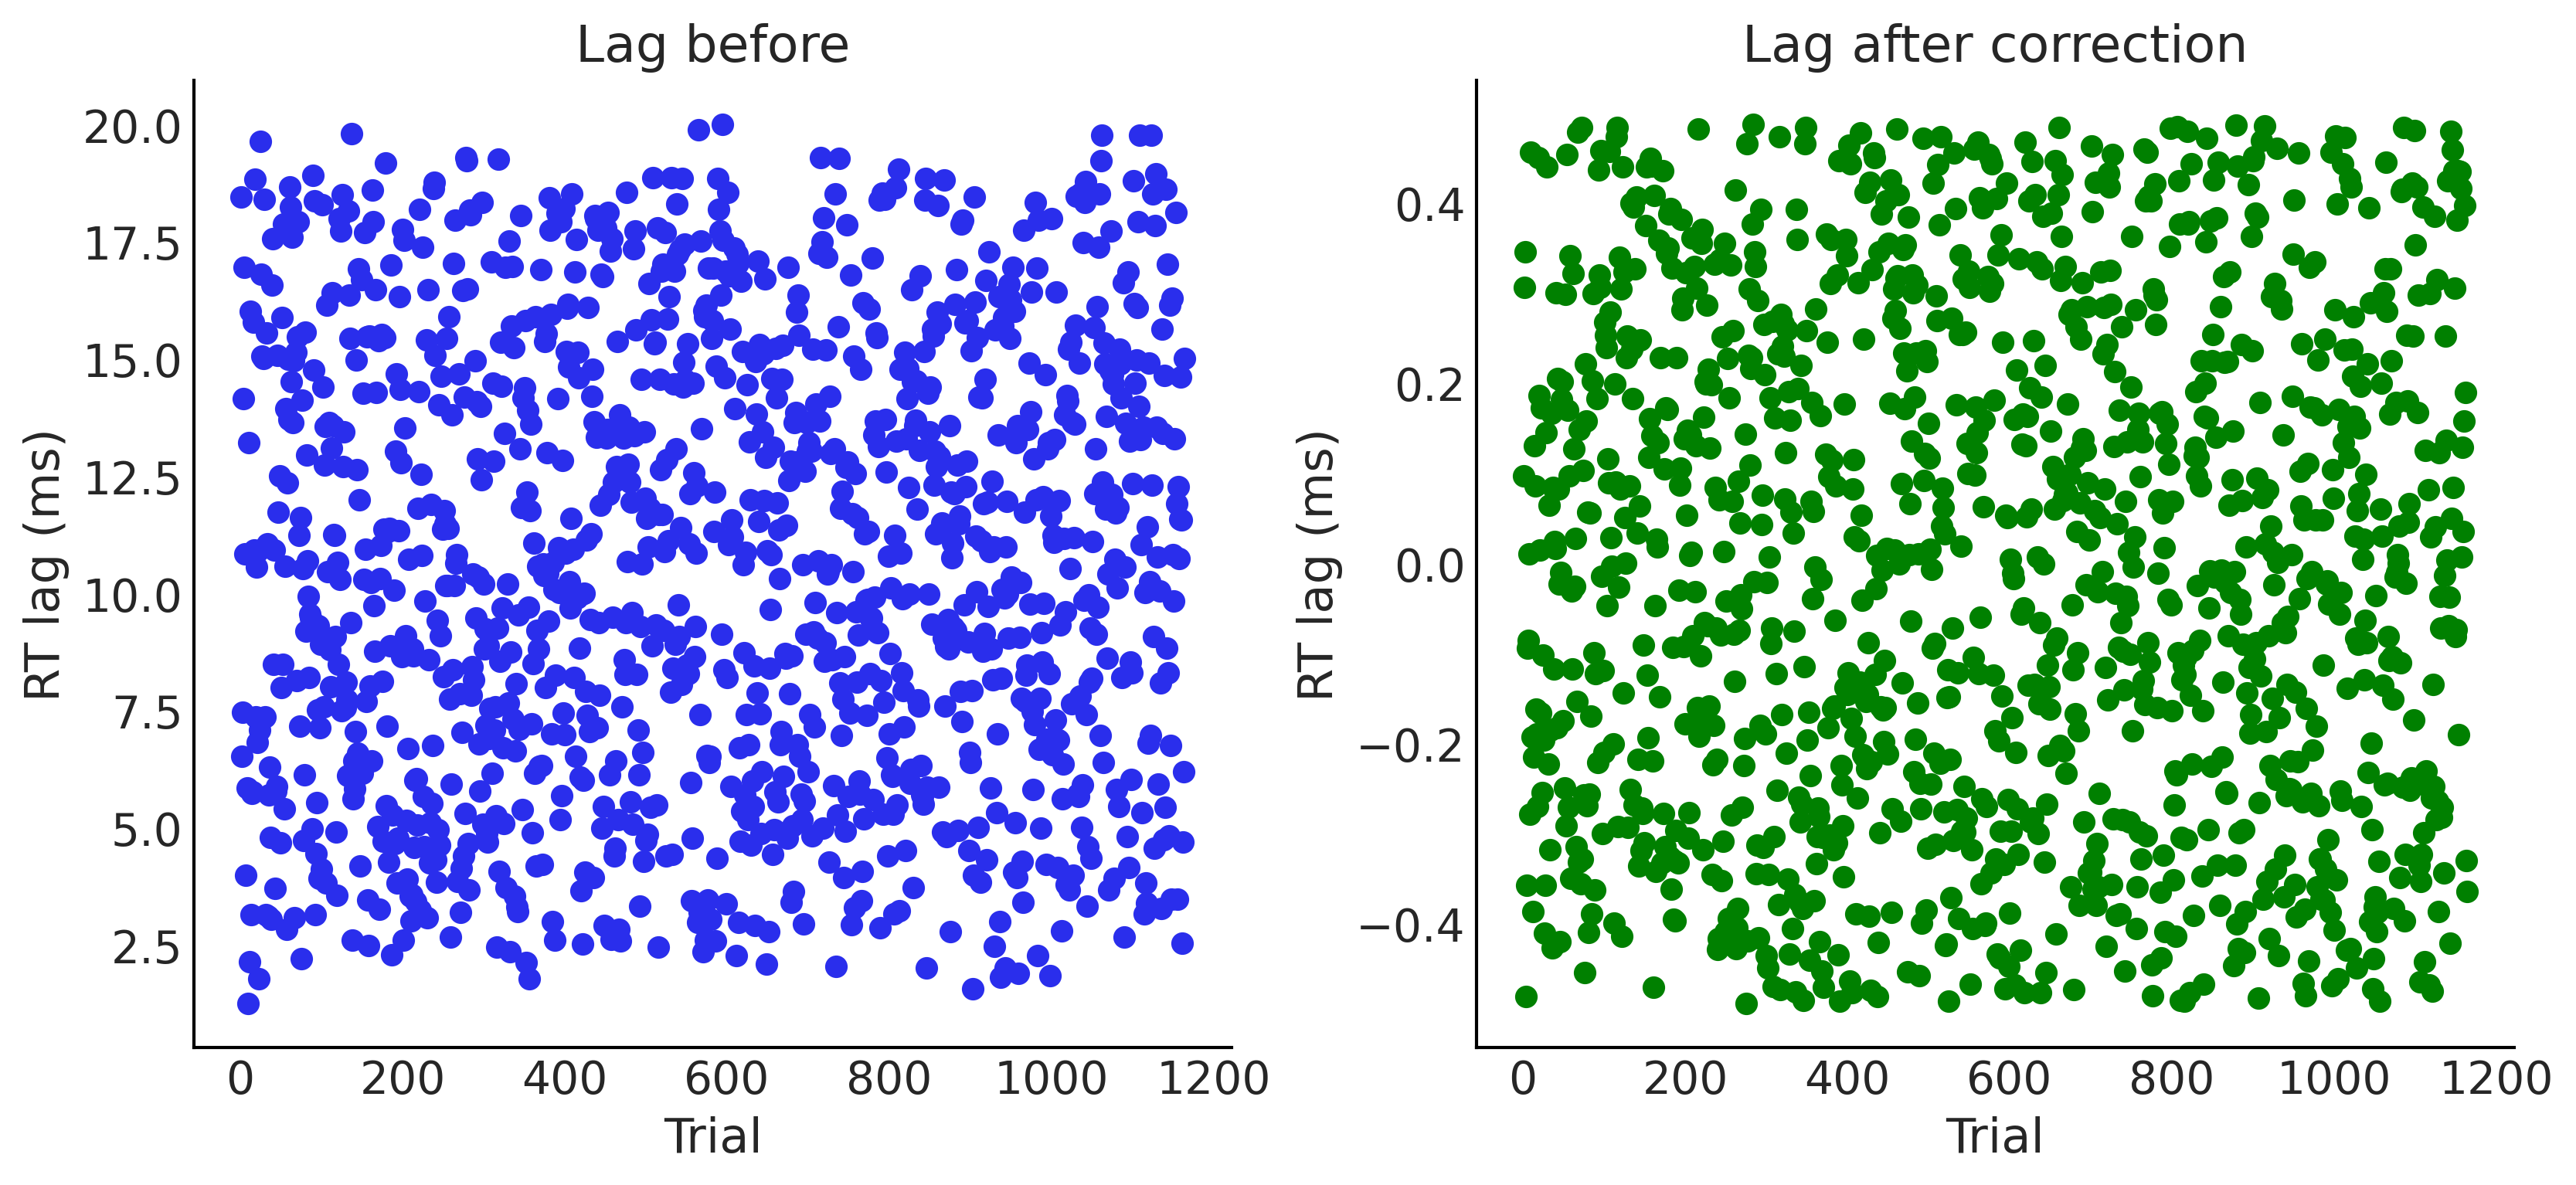

In [10]:
# --- Plot before lag event ---
fig, axs = plt.subplots(1, 2, figsize=(11, 5), dpi=300)

x = np.arange(1, len(lag_before) + 1)
y = lag_before

plt.subplot(1, 2, 1)
plt.plot(x, y, marker="o", linestyle="")

plt.title("Lag before")
plt.xlabel("Trial")
plt.ylabel("RT lag (ms)")


# --- Plot after lag event ---
x = np.arange(1, len(lag_after) +1)
y = lag_after

plt.subplot(1, 2, 2)
plt.plot(x, y, marker="o", linestyle="", color = "green")

plt.title("Lag after correction")
plt.xlabel("Trial")
plt.ylabel("RT lag (ms)")

Save your EMG and RT corrected triggers data:

In [11]:
save_fif = True # to do overwrite

if save_fif: 
    corrected_events = np.insert(corrected_events, 1, raw_events[:,1], axis=1) # add corresponding channel code to the corrected events array
    os.chdir(os.path.join(current, "EMG_processing", "processed_data_STEP1", "triggers"))
    np.save(f'{nameSubj}_corrected_triggers.npy', corrected_events[:] ) 
    
    os.chdir(os.path.join(current, "EMG_processing", "processed_data_STEP1", "EMG_signals"))
    # raw_bipolar_filtered.save(f'{nameSubj}_EMGstep1.fif', overwrite=True)
    print(">> Corrected triggers and FIF file saved.")
else: 
    print(">> Not saved")

>> Corrected triggers and FIF file saved.


## Step 2 - EMG Onset/Offset automatic detection with algorith

### Theoretical foundations
It is important to remember that although many methods have been proposed to determine the start and end of EMG peaks, none has proven as effective as human visual detection. The detection presented here is based on the MyOnset/EMG toolbox (https://github.com/lspieser/myonset); more specifically, the procedure described in Achard et al. (2025, JEP: General) appendix A and B for onset detection over large epochs (https://dx.doi.org/10.1037/xge0001748). You can also see Servant et al. (2021, JEP: General) and Dendauw et al. (2024, Psych Rev).

**Appendix B from Achard et al. (2025): EMG Onset Detection**

In each experiment, we applied the following three-step method to the rectified EMG signals to detect onsets. The first step allowed us to identify time windows of active EMG activity. For each epoch and EMG channel, we first computed the mean Mb and standard deviation SDb of the signal in the baseline period (from the beginning of the epoch to stimulus onset). Time windows of EMG activity corresponded to time windows in which the amplitude of the signal exceeded the following criterion:

$$critère = Mb + 7 × SDb$$

This algorithm was applied to the entire epoch. Due to the oscillatory nature of EMG activity, the amplitude of the signal can
sometimes fall below the criterion during an EMG burst. We thus merged consecutive time windows of EMG activity separated
by less than 0.025 s. To further increase the robustness of EMG detection in the presence of background noise, we discarded periods of active EMG activity with a duration < n + 3 samples (since the sampling frequency of our recordings is 1,024 Hz, one sample corresponds to 0.98 ms), where n corresponded to the number of time windows per second with a duration <7 samples (estimated on the whole epoch). Finally, we removed time windows before stimulus onset and after the response. This algorithm has the advantage of making minimal assumptions regarding the minimal duration of an EMG burst (because there is no theory specifying how long an EMG burst should be) while increasing the detection criterion in the presence of background noise.

The above method allowed us to identify time windows of active EMG activity, but it is known to overestimate EMG onsets
(especially when a conservative criterion is used). To address this problem, we applied the EMG onset detection algorithm proposed by Santello and McDonagh (1998) to each window (see also Liu & Liu, 2016). Finally, all triggers relative to stimulus and response identification were removed, and each trial was visually inspected by the experimenter. Erroneous EMG onsets were manually corrected.

### 2.1. Load data

In [12]:
# Select subject ---------------
nameSubj = 's1'

# Load EMG signal data ---------------
os.chdir(os.path.join(current, "EMG_processing", "processed_data_STEP1", "triggers"))
triggers = np.load(nameSubj +"_corrected_triggers.npy")

os.chdir(os.path.join(current, "EMG_processing", "processed_data_STEP1", "EMG_signals"))
EMGdata = mne.io.Raw(nameSubj + "_EMGstep1.fif", preload = True) #, exclude=65591)
sf = EMGdata.info['sfreq']

EMGdata

C:\Users\erc\AppData\Local\Temp\ipykernel_14792\3498670600.py:9: RuntimeWarning: This filename (s1_EMGstep1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  EMGdata = mne.io.Raw(nameSubj + "_EMGstep1.fif", preload = True) #, exclude=65591)


<Raw | s1_EMGstep1.fif, 2 x 2980864 (2911.0 s), ~45.5 MiB, data loaded>

### 2.2. Organize event (tmin, tmax, epoch, triggers, etc.)
Next, we prepare data:
- Organizes events from triggers (samples, codes, channels) into an Events structure.
- Segments the EMG data into epochs centered on the stimulus onset (window, e.g.,: -1.3s to +2.6s).
- Extracts the epochs and generates a time vector to synchronize the data with the stimulus.

In [13]:
#-------------------------------------------------------
# ----- Organise events before EMG onset detection -----
#-------------------------------------------------------
events = Events(sample = triggers[:,0], code = triggers[:,2], chan = [-1]*triggers[:,0].shape[0], sf=sf)
print ("> Events sucessfully organized")


#-------------------------------------------------------
# ----- Segment data into epochs time-locked on stimulus onset (so the 0 of time corresponds to stimulus onset)
#-------------------------------------------------------
# Interval used for segmentation, in seconds
tmin = -0.3 
tmax = 2.6 #which corresponds to 2.5s of response window 

# Extract EMG data
EMG_data_extracted = EMG_data

#  Trigg stim id
trigg_stim_id = np.array( [1, 2, 3, 4, 6, 7, 8, 9] ) # possible stimulus triggers 
trigg_resp_id = {'left_correct': 101, 'left_incorrect': 100, 'right_correct' : 103, 'right_incorrect':102, 'no_resp':200}

# Determine events corresponding to stimulus onset
epEvts = events.segment(codeT0=list(trigg_stim_id), tmin=tmin, tmax=tmax)

# Extract data epochs based on these events (stimulus onset)
dataEpochs = evt.getDataEpochs(EMG_data_extracted, epEvts)  # shape (n_epochs, n_channels, n_times)

# Extract time vector for the epoch (with a 1024 Hz sampling rate)
epochTime = evt.times(tmin, tmax, sf) # np vector array containing real time values for the epoch

print ("> Epochs sucessfully organized")

> Events sucessfully organized
Found 1164 epoch(s).
> Epochs sucessfully organized


#### Plot EMG signal
You can plot EMG signal as follow:

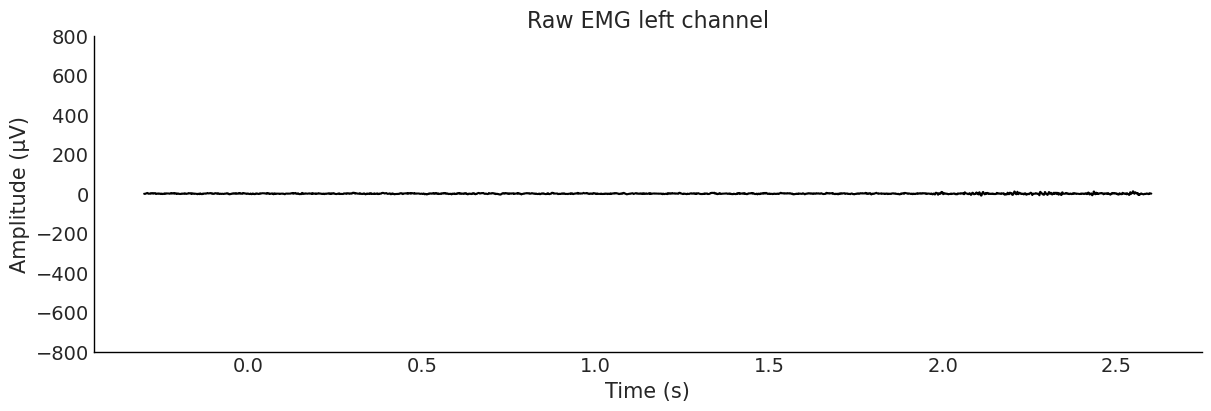

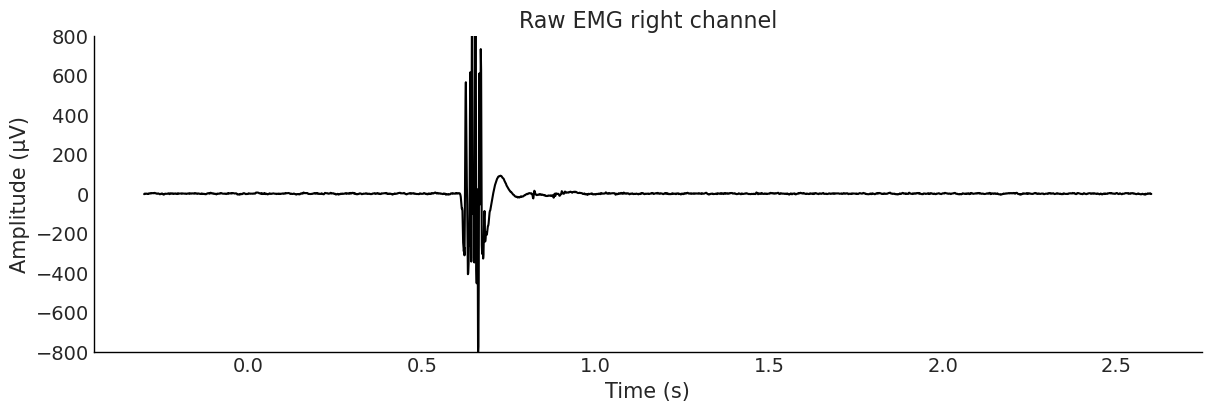

In [14]:
trial = 0
sig_raw = dataEpochs[trial, :, :] * 1e6  # Convert to microvolts


chan = 0  # 0 for EMGL, 1 for EMGR
signal_plot = sig_raw[chan, :]
time = epochTime

plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("Raw EMG left channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-800, 800])
plt.show()

chan = 1
signal_plot = sig_raw[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("Raw EMG right channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-800, 800])
plt.show()

#### Illustration of EMG detection method (`not run`)

(1) This code calculates a detection threshold for the EMG using the mean + 7 standard deviations of the baseline period (before the stimulus). It then displays the raw signal from the right channel with this threshold in red to visualize the onsets of muscle activity.

Mb = [ 0.1504  -0.07086]
SDb = [1.31233 1.71803]
Threshold = [ 9.33674 11.95532]


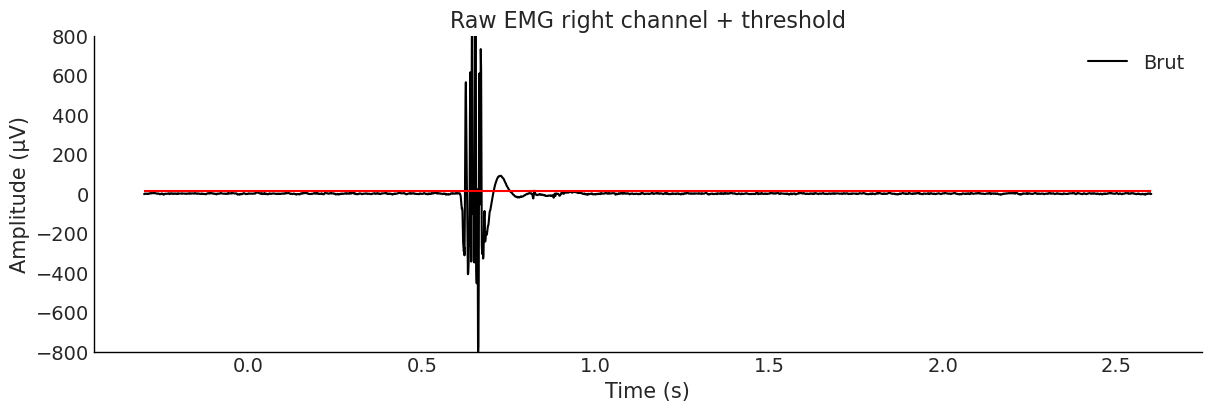

In [15]:
# Index du temps 0
idx_t0 = emg.findTimes(0., epochTime)
baseline_idx = np.arange(0, idx_t0)

# Moyenne et SD de la baseline par canal
Mb = np.mean(sig_raw[:, baseline_idx], axis=1)
SDb = np.std(sig_raw[:, baseline_idx], axis=1)

criterion = Mb + 7 * SDb

print("Mb =", Mb)
print("SDb =", SDb)
print("Threshold =", criterion)


# -- Plot criterio seuil on right channel  --
chan = 1
signal_plot = sig_raw[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, label="Brut", color = 'black')
plt.hlines(criterion[chan], time[0], time[-1], colors='red', linestyles='-')
plt.title("Raw EMG right channel + threshold")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-800, 800])
plt.show()

(2) This code rectifies the EMG signal (absolute value), then smoothes the envelope via a moving average (10 ms window). It finally displays the 3 versions of the signal (raw, rectified, smoothed) for the right channel.

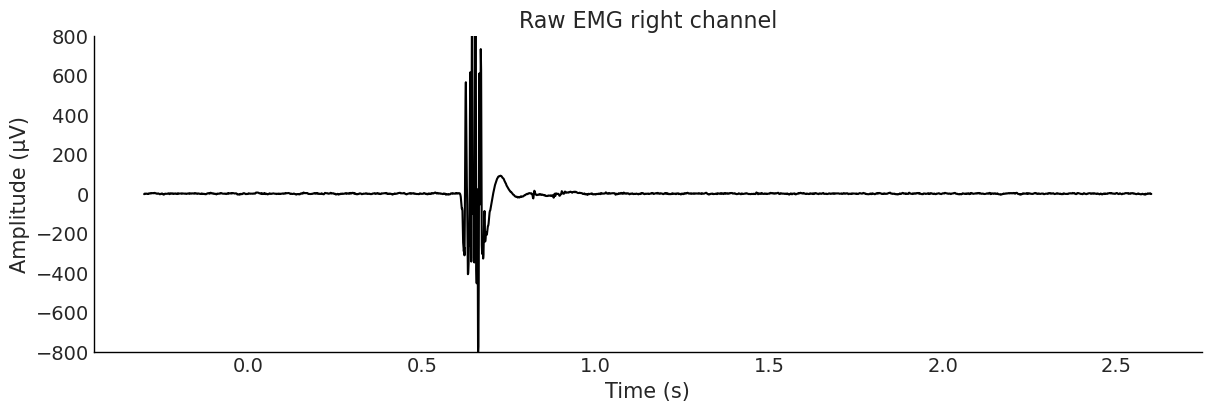

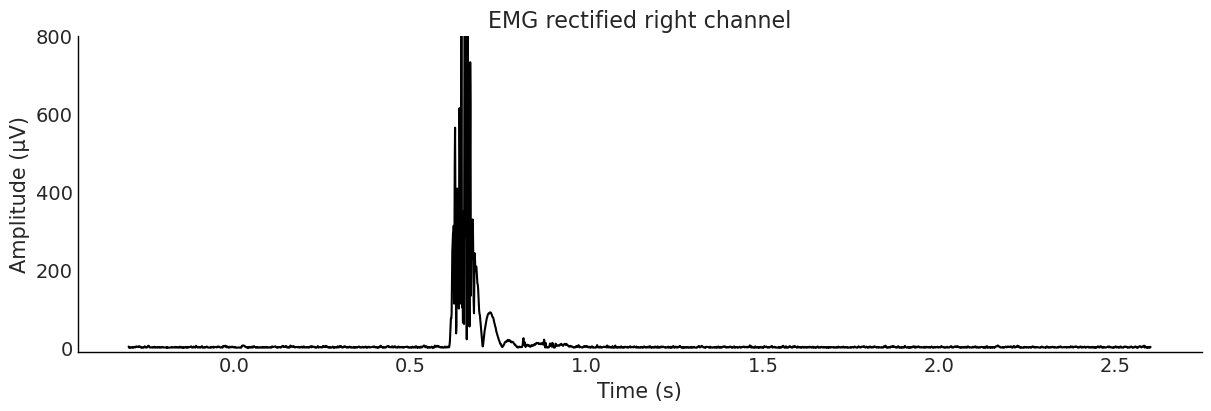

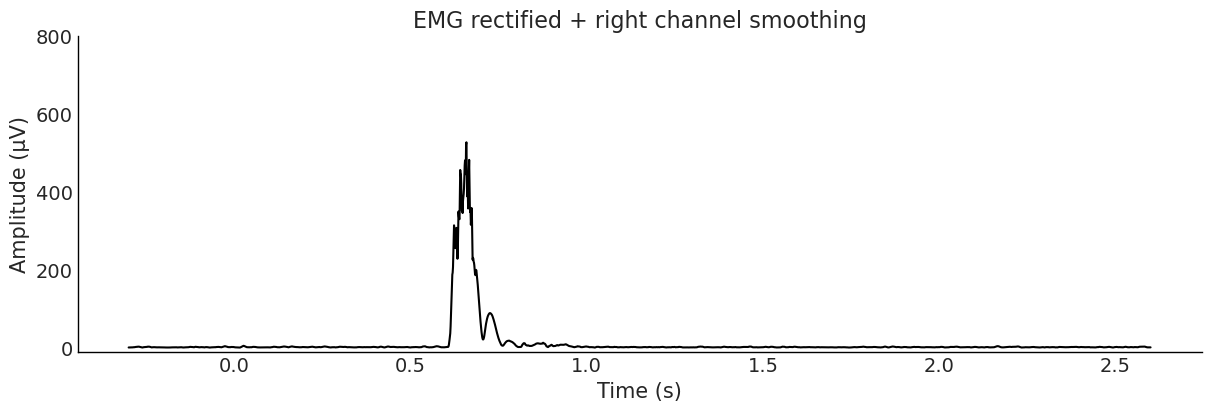

In [16]:
# Rectification
sig_rect = np.abs(sig_raw)

# Enveloppe via moyenne mobile 10 ms
sf = epEvts.sf
win_ms = 10
win_samples = max(1, int(win_ms * 1e-3 * sf))
kernel = np.ones(win_samples) / win_samples

env = np.vstack([
    np.convolve(sig_rect[ch], kernel, mode='same')
    for ch in range(2)
])



# --- Plots signal Raw vs rectified ---
chan = 1
signal_plot = sig_raw[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("Raw EMG right channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-800, 800])
plt.show()

signal_plot = sig_rect[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("EMG rectified right channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-10, 800])
plt.show()


signal_plot = env[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("EMG rectified + right channel smoothing")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-10, 800])
plt.show()

(3) The following code simulates algorithm detection with a final plot, as follows:
- Find segments where the envelope exceeds the threshold
- Merge windows separated too closely (< 25ms)
- Remove windows that are too short (minimum duration = n + 3 samples)
- Remove windows before t=0 or after the response

idx_t0 = 308 resp_lat = 999 epoch_len_samples = 2972


C:\Users\erc\AppData\Local\Temp\ipykernel_14792\4173306070.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


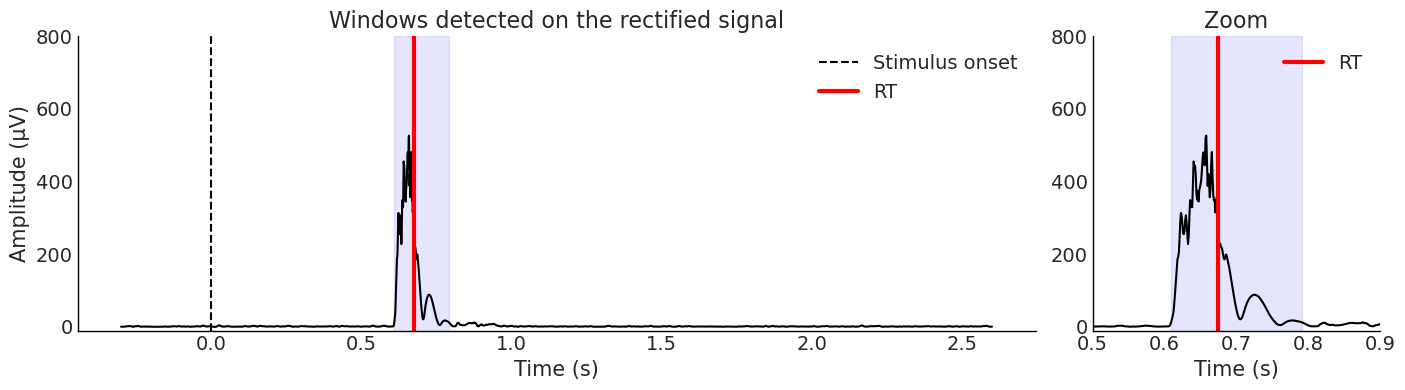

In [17]:
# Functions --------------------------------------
def get_windows_above_threshold(envelope, thr):
    above = envelope > thr
    diff = np.diff(above.astype(int))

    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1

    if above[0]:
        starts = np.insert(starts, 0, 0)
    if above[-1]:
        ends = np.append(ends, len(above))
    return np.array(list(zip(starts, ends)), dtype=int)

def merge_windows(wins, tol_s, sf):
    if len(wins) == 0:
        return wins
    tol = int(round(tol_s * sf))
    merged = []
    cur_s, cur_e = wins[0]

    for s, e in wins[1:]:
        if s - cur_e <= tol:
            cur_e = e
        else:
            merged.append((cur_s, cur_e))
            cur_s, cur_e = s, e
    merged.append((cur_s, cur_e))
    return np.array(merged, dtype=int)

def prune_short_windows(wins, sf, epoch_len):
    small = sum((e - s) < 7 for s,e in wins)
    n = small / (epoch_len / sf)
    min_len = int(np.ceil(n + 3))
    kept = np.array([(s,e) for (s,e) in wins if (e - s) >= min_len], dtype=int)
    return kept, min_len


def crop_windows(wins, t0, tResp):
    cropped = [
        (max(s, t0), e)
        for s, e in wins
        if e > t0 and s < tResp
    ]

    if len(cropped) == 0:
        return np.empty((0, 2), dtype=int)

    return np.array(cropped, dtype=int)


# Perform example detection ----------------------------------------------------------
# remember that criterion = Mb + 7 * SDb
wins_raw = {ch: get_windows_above_threshold(env[ch], criterion[ch]) for ch in [0,1]}
wins_merged = {ch: merge_windows(wins_raw[ch], 0.025, sf) for ch in [0,1]}

epoch_len_samples = sig_raw.shape[1]
wins_pruned = {}
min_lengths = {}
for ch in [0,1]:
    wins_pruned[ch], min_lengths[ch] = prune_short_windows(wins_merged[ch], sf, epoch_len_samples)


# Récupération latence réponse
stim_list = epEvts.listEvtsTrials[trial].findEvents(code=list(trigg_stim_id))
resp_list = epEvts.listEvtsTrials[trial].findEvents(code=list(trigg_resp_id.values()))

if len(resp_list) > 0:
    resp_latency = epEvts.listEvtsTrials[trial].Latency.sample[resp_list[resp_list > stim_list[0]][0]]
else: 
    resp_latency = tmax * epEvts.sf # if no response, resp latency is equal to tmax

idx_t0 = emg.findTimes(0, epochTime) #  index time 0 (début stimulus)
print("idx_t0 =", idx_t0, "resp_lat =", resp_latency, "epoch_len_samples =", epoch_len_samples)

wins_final = {ch: crop_windows(wins_pruned[ch], idx_t0, resp_latency) for ch in [0,1]}




# Plot result of EMG detection ------------------------------------------------
chan = 1 
signal_plot = env[chan, :]
rt_time = epochTime[int(resp_latency)]

fig, axes = plt.subplots(1, 2, figsize=(14,4), gridspec_kw={'width_ratios': [1, 0.3]})

axes[0].plot(epochTime, signal_plot, color='black')
for (start, end) in wins_final[chan]:
    axes[0].axvspan(epochTime[start], epochTime[end-1], color='blue', alpha=0.1)
axes[0].set_title("Windows detected on the rectified signal")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].axvline(0, color='k', linestyle='--', label='Stimulus onset')
axes[0].axvline(rt_time, color='red', lw = 3,  linestyle='-', label='RT')
axes[0].set_ylim([-10, 800])
axes[0].legend()


# Zoom ----------
axes[1].plot(epochTime, signal_plot, color='black')
for (start, end) in wins_final[chan]:
    axes[1].axvspan(epochTime[start], epochTime[end-1], color='blue', alpha=0.1)
axes[1].set_title("Zoom")
axes[1].set_xlabel("Time (s)")
axes[1].set_xlim([0.5, 0.9])
axes[1].axvline(rt_time, color='red', lw = 3,  linestyle='-', label='RT')
axes[1].legend()
axes[1].set_ylim([-10, 800])
plt.tight_layout()
plt.show()

### 2.3. Run EMG detection

All procedure explain before, just be careful to select desired parameters for detection.

In [18]:
#use parameters from Edouard's published paper 
parameters = {                      
                            # Set threshold for detection of active EMG windows
    'thEMG_raw': [7,7],     # multipler of the baseline variance to compute threshold  recommended 3-7
    'thEMG_tk': [8,8],      # Teager-Kayser EMG   multipler of the baseline variance to compute threshold recommended 8 to 12
    'lowest_delay': .025,   # Lowest time delay (in second) between bursts for raw signal recommended .015 to .035s 
    'smallest_burst': 3,    # Minimal number of samples exceeding threshold to define a burst recommended 1 to 5
    'useRaw': True,         # Set whether to use raw and/or Teager-Kayser EMG for active EMG windows detection
    'useTkeo': False
    }

trigg_emg_id = {'onset': 350 , 'offset': 351 }

def EMG_detection_toolbox(dataEpochs, parameters, epEvts):

    # --------- Read parameters -----------
    thEMG_raw      = parameters['thEMG_raw']
    thEMG_tk       = parameters['thEMG_tk']
    lowest_delay   = parameters['lowest_delay']
    smallest_burst = parameters['smallest_burst']
    useRaw         = parameters['useRaw']
    useTkeo        = parameters['useTkeo']
        
    ######## START THE EMG DETECTION ##############
    # get index of time 0 
    t0 = emg.findTimes(0, epochTime)
    emg_channels_idx = {0: 'EMGL', 1: 'EMGR'}

    trigg_resp_id = {'left_correct': 101, 'left_incorrect': 100, 'right_correct' : 103, 'right_incorrect':102, 'no_resp':200}
    trigg_emg_id = {'onset': 350 , 'offset': 351 }


    mBlRaw,stBlRaw = emg.getGlobalVariance(dataEpochs, epochTime, corVar=2.5, useTkeo=False)
    mBlTk,stBlTk = emg.getGlobalVariance(dataEpochs, epochTime, corVar=2.5, useTkeo=True)
    # getGlobalVariance: concatenate the baseline of each epoch, and computes mean (mBl) and standard deviation (stBl) of the concatenated data
    print('Detecting onset ...')

    # do the automatic detection
    onset = []#store onsets relative to continuous signal (in sample unit)
    onset_chan = []#for each onset, specify EMG channel
    offset = []#store offsets relative to continuous signal (in sample unit)
    offset_chan = []#for each offset, specify EMG channel

    for e in range(epEvts.nbTrials()):#loop over epochs
        for c in emg_channels_idx.keys():#loop over channels
            current = dataEpochs[e,c,:]
            onsets,offsets = emg.getOnsets(current, epochTime, sf = epEvts.sf,\
                    thRaw = thEMG_raw[c], useRaw = useRaw, time_limitRaw = lowest_delay, min_samplesRaw = smallest_burst, varying_minRaw = 1, mBlRaw = None, stBlRaw = None, \
                    thTkeo = thEMG_tk[c], useTkeo = useTkeo, time_limitTkeo = lowest_delay,  min_samplesTkeo = smallest_burst, varying_minTkeo = 0, mBlTkeo = None, stBlTkeo = None)    #local mBl and stBl are recommended, to use global values, use mBlRaw/mBlTk[c] and stBlRaw/stBlTk[c] computed above
            ####             
            # onsets and offsets are lists containing latencies (in sampling units) of EMG onsets and offsets respectively 
            ####

            # Removes burst starting before time 0
            offsets = [offsets[b] for b in range(len(offsets)) if (onsets[b] > t0)]
            onsets = [onsets[b] for b in range(len(onsets)) if (onsets[b] > t0)]
            
            
            # Removes bursts starting after the first response
            stim = epEvts.listEvtsTrials[e].findEvents(code=list(trigg_stim_id))# get index of stim trigg
            resp = epEvts.listEvtsTrials[e].findEvents(code=list(trigg_resp_id.values()))# get index of resp trigg
            
            if len(resp) > 0:
                #get latency of the first response after the first stimulus (segments are large, and may thus contain triggers from subsequent trials)
                resp_latency = epEvts.listEvtsTrials[e].Latency.sample[resp[resp > stim[0]][0]]
            else: 
                resp_latency = tmax * epEvts.sf # if no response, resp latency is equal to tmax
            offsets = [offsets[b] for b in range(len(offsets)) if (onsets[b] < resp_latency)]
            onsets = [onsets[b] for b in range(len(onsets)) if (onsets[b] < resp_latency)]

            # store the onsets and offsets
            onset.extend(onsets + epEvts.tmin.sample[e])
            onset_chan.extend([c] * len(onsets))
            
            # save the offset(s)
            offset.extend(offsets + epEvts.tmin.sample[e])
            offset_chan.extend([c] * len(offsets))        
            
    print('Detection completed')

    # organize EMG onsets
    evtOnsets = Events(sample=onset , chan=onset_chan , code=[trigg_emg_id['onset']] * len(onset) , sf=epEvts.sf)


    # organize EMG offsets
    evtOffsets = Events(sample=offset , chan=offset_chan , code=[trigg_emg_id['offset']] * len(offset) , sf=epEvts.sf)
    auto_events = events.copyEvents()#make a copy of original events 
    auto_events.addEvents(evtOnsets)#add EMG onsets
    auto_events.addEvents(evtOffsets)#add EMG offsets


    #----------------------------------------------------------------------------------
    #--Segment data again, but this time the data contain EMG onsets and EMG offsets----
    #----------------------------------------------------------------------------------
    epEvts = auto_events.segment(codeT0=list(trigg_stim_id), tmin=tmin, tmax=tmax)  



    ####### ---------------------------------
    #remove stimulus ond response markers that belong to the next trial (segmentation is large, and likely contain these)
    for e in range(epEvts.nbTrials()):#loop over epochs
        code = epEvts.listEvtsTrials[e].code
        chan = epEvts.listEvtsTrials[e].chan
        time = epEvts.listEvtsTrials[e].Latency.time

        # Finds the index at which trial ends (after offset(s) of all bursts starting before the last response occured
        endIdx = evt.idxEndEvent(code, chan, time, list(trigg_stim_id), trigg_resp_id.values(),\
                                onsetCodes=trigg_emg_id['onset'], offsetCodes=trigg_emg_id['offset'],\
                                minStim=1, maxStim=1, minResp=0, maxResp=1, \
                                stop_after_response=False, stop_after_offset=True)

        epEvts.listEvtsTrials[e].delEvents(range(endIdx + 1,epEvts.listEvtsTrials[e].nbEvents()), printDelEvt=False)#remove stimulus and response markers after offset(s) of all bursts starting before the last response occured

    return epEvts


epEvts = EMG_detection_toolbox(dataEpochs, parameters, epEvts)

Detecting onset ...
Detection completed
Found 1164 epoch(s).


**Note:**
If you use too long a period before t0 (stimulus onset), you'll get the previous responses and the algorithm will stop recording EMG bursts at the first response it finds... I advise you to segment from -0.3s to +2.6s centered on the stimulus onset for greater safety.

In [19]:
#--- Memo ---
# epEvts.listEvtsTrials  epEvts.listEvtsTrials[e] contains triggers and corresponding latencies for epoch e
# epEvts.listEvtsTrials[0].code  returns np.array containing triggers from epoch e
# epEvts.listEvtsTrials[0].Latency.sample  returns np.array containing latency (in samples) of triggers from epoch e
# epEvts.listEvtsTrials[0].Latency.time  returns np.array containing latency (in ms) of triggers from epoch e
# epEvts.listEvtsTrials[0].findEvents(sample = OR  time = OR code= OR channel) finds the specified event(s) and returns the position(s).
# epEvts.nbTrials()   interger number of epochs

#--- relationship with continuous signal: 
#epEvts.tmin.time np vector array   tmin[n] contains starting latency of epoch n in continuous signal
#epEvts.t0.time np vector array   t0[n] contains latency of locking event of epoch n in continuous signal
#epEvts.tmax.time np vector array   tmax[n] contains ending latency of epoch n in continuous signal
#epEvts.nbTrials()   interger number of epochs

Create a viz window, then save result detection:

In [20]:
#----------------------------------------------------------------------------------
# Visualize EMG data with EMG onset and offset markers, in order to correct them if necessary 
#----------------------------------------------------------------------------------

viz = vizEMG.VizApplication(sys.argv)
viz.loadData(dataEpochs,epochTime, epEvts, codeMovable1=trigg_emg_id['onset'],codeMovable2=trigg_emg_id['offset'])#codeMovable determines the markers that you will be able to move (don't do that with stimulus and response triggers)

# viz.show() # if you want to see signal

saving = True # carefull to not overwrite on segmented data that you have visualy inspecti in next step.
if saving:
    vizEvts = viz.getEvents()
    os.chdir(os.path.join(current, "EMG_processing", "processed_data_STEP2", "segmented"))
    vizEvts.saveAsCSV(f'{nameSubj}_segmentedEvts.csv')

    os.chdir(os.path.join(current, "EMG_processing", "processed_data_STEP2", "continuous"))
    vizEvts.saveContinuousAsCSV(f'{nameSubj}_continuousEvts.csv')
    
    print('Saved.')
else:
    print('Not saved.')

Saving as segmented...
Saving as continuous...
Checking for duplicates in events...
0 event(s) removed.
Saved.


## Step 3 - Viz data, load and visual inspection of EMG onset/offset

Here, I recommend **not running step 3 code in this notebook** to avoid overwriting the detection method based on your correct visual inspection of the EMG data in Step 3 in case of an error. Instead, create a new Python file with the following code:


In [21]:
# Select subject -----------------------------------------
nameSubj = 's1'

# Load EMG signal data -----------------------------------
os.chdir(os.path.join(current, "EMG_processing", "processed_data_STEP1", "EMG_signals"))
EMGdata = mne.io.Raw(nameSubj + "_EMGstep1.fif", preload = True) #, exclude=65591)
sf = EMGdata.info['sfreq']



# Load partially marked segments--------------------------
segmented = os.path.join(current, "EMG_processing", "processed_data_STEP2", "segmented")
continuous = os.path.join(current, "EMG_processing", "processed_data_STEP2", "continuous")

# Segment data into epochs
markers_segmented_stim_locked = evt.loadSegmented(os.path.join(segmented, nameSubj + "_segmentedEvts.csv"),headerlines=1, sep=',', sf=sf,
                  colSample=0, colTime=1, colCode=2, colChan=3,
                  colTrialIdx=4, 
                  colTminSample=5, colTminTime=6,
                  colT0Sample=7, colT0Time=8, 
                  colTmaxSample=9, colTmaxTime=10)

#interval used for segmentation, in seconds - to be sure that is the same as step 2 
tmin = -0.3 # if more not detect doccret stimulus onset trial
tmax = 2.6 #2.6 is afeter missed triak


######Get data segments corresponding to given EpochEvents.
dataEpochs_stim_locked = evt.getDataEpochs(EMG_data_extracted, markers_segmented_stim_locked)# Contains data segments (axis 0: trials, axis 1: channels, axis 2: voltage data) so (1152, 2, voltage values)
epochTime = evt.times(tmin, tmax, sf)# np vector array containing real time values for 1 epoch with a 1024 Hz sampling 
trigg_emg_id = {'onset': 350 , 'offset': 351}


# ----------------- Visualation window EMG --------------------------
viz = vizEMG.VizApplication(sys.argv)
viz.loadData(dataEpochs_stim_locked,epochTime, markers_segmented_stim_locked, codeMovable1=trigg_emg_id['onset'],codeMovable2=trigg_emg_id['offset'])
viz.show()




# --------------- SAVE (always) ----------------
#as usual, uncomment and execute the lines below to save your edits.
vizEvts = viz.getEvents()
os.chdir(segmented)
vizEvts.saveAsCSV(os.path.join(segmented, nameSubj + '_segmentedEvts.csv'))
os.chdir(continuous)
vizEvts.saveContinuousAsCSV(os.path.join(continuous, nameSubj + '_continuousEvts.csv'))
print("continuousEvts and segmentedEvts saved")



C:\Users\erc\AppData\Local\Temp\ipykernel_14792\2583585738.py:6: RuntimeWarning: This filename (s1_EMGstep1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  EMGdata = mne.io.Raw(nameSubj + "_EMGstep1.fif", preload = True) #, exclude=65591)


Saving as segmented...
Saving as continuous...
Checking for duplicates in events...
0 event(s) removed.
continuousEvts and segmentedEvts saved


In [22]:
# [x] End of EMG processing pipeline.

In [23]:
# Just check if all is OK ---------------------------------------------------------------------------------------

stim_codes = list(trigg_stim_id)
resp_codes = list(trigg_resp_id.values())

bad_trials = []
good_trials = []

for i in range(epEvts.nbTrials()):

    code = np.asarray(epEvts.listEvtsTrials[i].code)
    latency = np.asarray(epEvts.listEvtsTrials[i].Latency.sample)

    # Indices des triggers stimulus et réponse dans l'essai
    stim_idx = np.where(np.isin(code, stim_codes))[0]
    resp_idx = np.where(np.isin(code, resp_codes))[0]

    # Vérifie présence stimulus
    if len(stim_idx) == 0:
        bad_trials.append({
            "trial": i,
            "error": "missing_stimulus",
            "codes": code
        })
        continue

    # Vérifie présence réponse
    if len(resp_idx) == 0:
        bad_trials.append({
            "trial": i,
            "error": "missing_response",
            "codes": code
        })
        continue

    # On prend le premier stimulus de l'essai
    first_stim_idx = stim_idx[0]
    first_stim_latency = latency[first_stim_idx]

    # Réponses après le stimulus
    resp_after_stim = resp_idx[latency[resp_idx] > first_stim_latency]

    if len(resp_after_stim) == 0:
        bad_trials.append({
            "trial": i,
            "error": "response_before_stimulus_or_no_response_after",
            "stim_latency": first_stim_latency,
            "resp_latencies": latency[resp_idx],
            "codes": code
        })
        continue

    # Première réponse après le stimulus
    first_resp_idx = resp_after_stim[0]
    first_resp_latency = latency[first_resp_idx]

    good_trials.append({
        "trial": i,
        "stim_code": code[first_stim_idx],
        "resp_code": code[first_resp_idx],
        "stim_latency": first_stim_latency,
        "resp_latency": first_resp_latency,
        "RT_samples": first_resp_latency - first_stim_latency,
        "RT_seconds": (first_resp_latency - first_stim_latency) / epEvts.sf
    })

print(f"Nombre d'essais corrects : {len(good_trials)}")
print(f"Nombre d'essais problématiques : {len(bad_trials)}")

for tr in bad_trials:
    print(tr)

Nombre d'essais corrects : 1164
Nombre d'essais problématiques : 0
